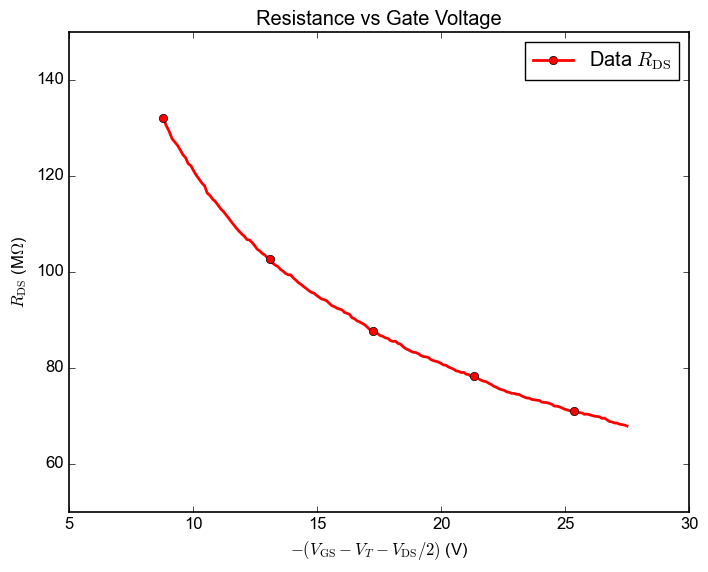

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

# IDS - VGS data
data = np.loadtxt("./Data-Mobility/data-50nA-analyse.dat")
V_GS = data[:, 0]  # VGS values
I_DS = data[:, 2]  # IDS values
V_DS = data[:, 3]  # VDS values
V_C = 0.5*(data[:, 4] + data[:, 5])
R_DS = V_DS / I_DS  # Calculate resistance
V_T = -10.1

x = V_GS - V_T - 0.5 * V_C

plt.plot(-x, R_DS*1e-6, lw=2, label=r'Data $R_\text{DS}$', color='red', marker='o', linestyle='-', markevery=40)
plt.xlabel(r"$-(V_\text{GS}- V_T - V_\text{DS}/2)$ (V)")
plt.ylabel(r"$R_\text{DS}$ (M$\Omega$)")
plt.xlim(5,30)
plt.ylim(50, 150)
plt.legend(frameon=True, loc='upper right', numpoints=1)
plt.title("Resistance vs Gate Voltage")
plt.show()


a = 3.90268e+07 ± 1.61e+05
b = -8.26028e+08 ± 2.52e+06
R^2 = 0.998332
--------------------------------------
Rc = (39.0268 ± 0.161) MΩ


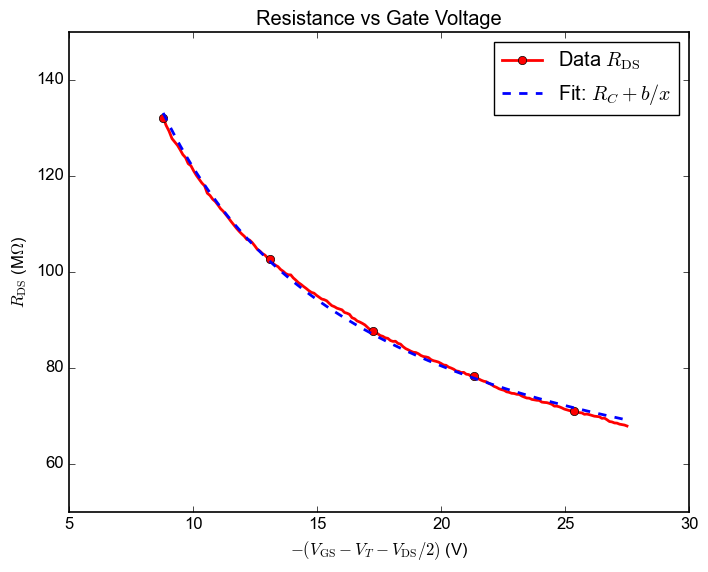

In [41]:
def func(x, a, b):
    return a + b / x

# Use only finite points in the requested fit window: 5 <= x <= 30
mask = np.isfinite(x) & np.isfinite(R_DS) 
x_fit = x[mask]
R_fit_data = R_DS[mask]

# Fit Rc + b/x to the selected x-range
popt, pcov = curve_fit(
    func,
    x_fit,
    R_fit_data,
    p0=(10, 10),
)
R_fit = func(x_fit, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((R_fit_data - R_fit) ** 2)
ss_tot = np.sum((R_fit_data - np.mean(R_fit_data)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr



R_fit = func(x_fit, a, b)


print(f"a = {a:.6g} ± {a_err:.3g}")
print(f"b = {b:.6g} ± {b_err:.3g}")
print(f"R^2 = {r2:.6f}")
print("--------------------------------------")
print(f"Rc = ({a*1e-6:.6g} ± {a_err*1e-6:.3g}) MΩ")

plt.plot(-x, R_DS*1e-6, lw=2, label=r'Data $R_\text{DS}$', color='red', marker='o', linestyle='-', markevery=40)
plt.plot(-x_fit, R_fit*1e-6, lw=2, label='Fit: $R_C + b/x$', color='blue', linestyle='--')
plt.xlabel(r"$-(V_\text{GS}- V_T - V_\text{DS}/2)$ (V)")
plt.ylabel(r"$R_\text{DS}$ (M$\Omega$)")
plt.xlim(5,30)
plt.ylim(50, 150)
plt.legend(frameon=True, loc='upper right', numpoints=1)
plt.title("Resistance vs Gate Voltage")
plt.show()